In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Federal Aviation Administration (FAA) Aircraft Wildlife Strike Database (1990–2023)

In [ ]:
# Read the Csv file into a dataframe
df = pd.read_csv("STRIKE_REPORTS.csv", low_memory=False)

In [ ]:
df.describe()

,INDEX_NR,INCIDENT_MONTH,INCIDENT_YEAR,LATITUDE,LONGITUDE,EMA,EMO,AC_MASS,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,HEIGHT,SPEED,DISTANCE,AOS,BIRD_BAND_NUMBER,NR_INJURIES,NR_FATALITIES
count,116452.000000,116452.000000,116452.000000,103430.000000,103430.000000,86615.000000,85796.000000,89519.000000,89542.000000,89235.000000,83995.000000,8839.000000,2010.000000,69128.000000,45717.000000,67309.000000,5286.000000,0.0,166.000000,4.000000
mean,673499.021125,7.146000,2004.170637,37.075890,-91.930377,21.842314,10.415882,3.526503,2.062429,2.964879,2.913328,3.136667,1.684080,869.706776,142.115690,0.568383,123.510499,NaN,1.289157,3.000000
std,36529.391418,2.828906,5.922657,6.989877,26.592056,10.964220,13.048713,0.855046,0.469993,2.077186,2.011643,1.974919,1.270015,1865.737454,46.334665,3.137847,464.824472,NaN,0.786710,3.366502
min,608242.000000,1.000000,1990.000000,-37.673333,-177.381000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,NaN,1.000000,1.000000
25%,642141.750000,5.000000,2000.000000,33.453710,-104.667000,10.000000,1.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,120.000000,0.000000,1.000000,NaN,1.000000,1.000000
50%,674444.500000,7.000000,2005.000000,38.944530,-87.904460,22.000000,7.000000,4.000000,2.000000,1.000000,1.000000,5.000000,1.000000,50.000000,138.000000,0.000000,6.000000,NaN,1.000000,1.500000
75%,705127.250000,9.000000,2009.000000,41.241840,-80.232870,34.000000,10.000000,4.000000,2.000000,5.000000,5.000000,5.000000,1.000000,800.000000,160.000000,0.000000,45.750000,NaN,1.000000,3.500000
max,736299.000000,12.000000,2015.000000,71.285450,178.559228,92.000000,97.000000,5.000000,4.000000,7.000000,6.000000,6.000000,5.000000,31300.000000,380.000000,95.000000,6950.000000,NaN,7.000000,8.000000


In [ ]:
def explore_data_quality(df):
    stats = []

    for col in df.columns:
        # Basic counts
        total_rows = len(df)
        non_empty = df[col].count()
        missing = total_rows - non_empty
        pct_missing = (missing / total_rows) * 100
        unique_vals = df[col].nunique()
        dtype = df[col].dtype

        # Identify "Hidden Nulls" (zeros in numeric columns like altitude or coordinates)
        zeros = 0
        if np.issubdtype(dtype, np.number):
            zeros = (df[col] ==0).sum()

        stats.append({
            'Column': col,
            'Dtype': dtype,
            'Unique': unique_vals,
            'Missing': missing,
            '% Missing': round(pct_missing, 2),
            'Zeros/Hidden Nulls': zeros,
        })

    return pd.DataFrame(stats)


# Set settings to see everything displayed
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Run the exploration
quality_report = explore_data_quality(df)
print(quality_report)



                   Column    Dtype  Unique  Missing  % Missing  \
0                INDEX_NR    int64  116452        0       0.00   
1           INCIDENT_DATE   object    8397        0       0.00   
2          INCIDENT_MONTH    int64      12        0       0.00   
3           INCIDENT_YEAR    int64      24        0       0.00   
4                    TIME   object    1431    71499      61.40   
5             TIME_OF_DAY   object       4    44570      38.27   
6              AIRPORT_ID   object    1911        0       0.00   
7                 AIRPORT   object    1911        0       0.00   
8                LATITUDE  float64    1901    13022      11.18   
9               LONGITUDE  float64    1902    13022      11.18   
10                 RUNWAY   object     413    31652      27.18   
11                  STATE   object      67    13022      11.18   
12              FAAREGION   object      10    13022      11.18   
13               LOCATION   object    4709   104398      89.65   
14        

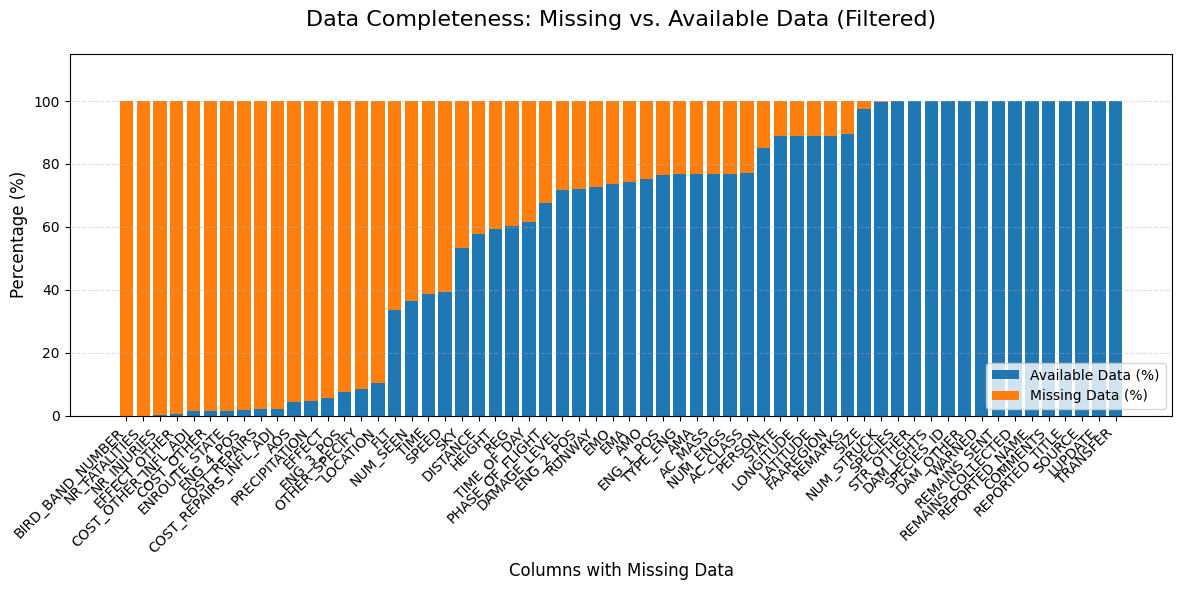

In [ ]:
def plot_missing_data_stacked_bar(df):
    # Calculate missing values
    missing_counts = df.isnull().sum()

    # Filter only columns that have missing data
    columns_with_missing = missing_counts[missing_counts > 0].index

    if len(columns_with_missing) == 0:
        print("Data is 100% complete! No missing values found.")
        return

    # Calculate percentages
    total_rows = len(df)
    missing_pct = (missing_counts[columns_with_missing] / total_rows) * 100
    available_pct = 100 - missing_pct

    # Create a temporary DataFrame for easy sorting
    plot_df = pd.DataFrame({
        'Available': available_pct,
        'Missing': missing_pct
    }).sort_values(by='Missing', ascending=False) # Sort by most missing first

    # Plotting
    plt.figure(figsize=(12, 6))

    # Plot Available (Blue)
    plt.bar(plot_df.index, plot_df['Available'], color='#1f77b4', label='Available Data (%)')

    # Plot Missing (Orange) on top of Available
    plt.bar(plot_df.index, plot_df['Missing'], bottom=plot_df['Available'],
            color='#ff7f0e', label='Missing Data (%)')

    # Formatting the chart
    plt.title('Data Completeness: Missing vs. Available Data (Filtered)', fontsize=16, pad=20)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xlabel('Columns with Missing Data', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 115) # Leave space at the top for labels/legend

    # Add a legend
    plt.legend(loc='lower right', frameon=True)

    # Add gridlines for easier reading
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_missing_data_stacked_bar(df)

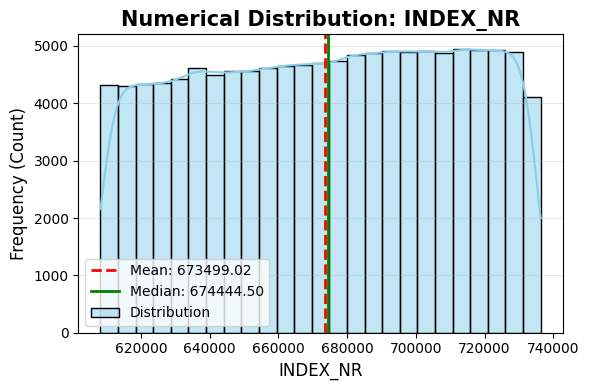

Skipping 'INCIDENT_DATE': This is a categorical/text column.


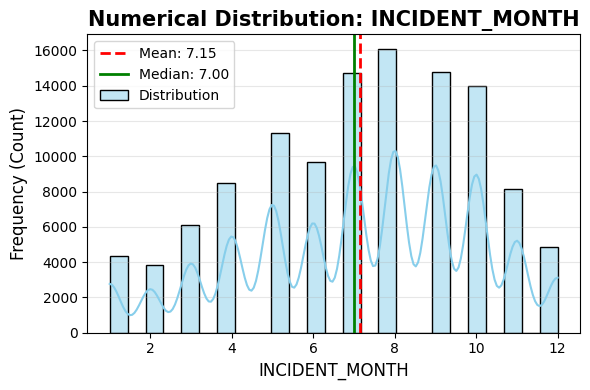

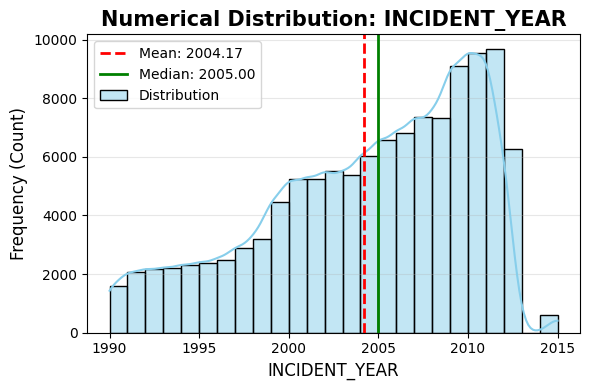

Skipping 'TIME': This is a categorical/text column.
Skipping 'TIME_OF_DAY': This is a categorical/text column.
Skipping 'AIRPORT_ID': This is a categorical/text column.
Skipping 'AIRPORT': This is a categorical/text column.


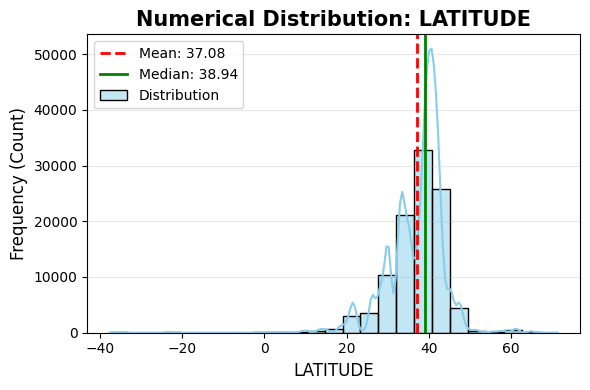

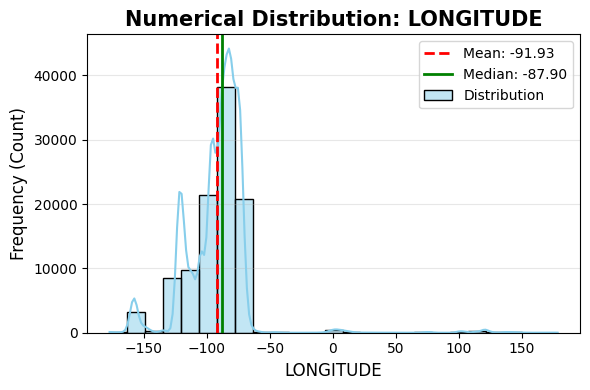

Skipping 'RUNWAY': This is a categorical/text column.
Skipping 'STATE': This is a categorical/text column.
Skipping 'FAAREGION': This is a categorical/text column.
Skipping 'LOCATION': This is a categorical/text column.
Skipping 'ENROUTE_STATE': This is a categorical/text column.
Skipping 'OPID': This is a categorical/text column.
Skipping 'OPERATOR': This is a categorical/text column.
Skipping 'REG': This is a categorical/text column.
Skipping 'FLT': This is a categorical/text column.
Skipping 'AIRCRAFT': This is a categorical/text column.
Skipping 'AMA': This is a categorical/text column.
Skipping 'AMO': This is a categorical/text column.


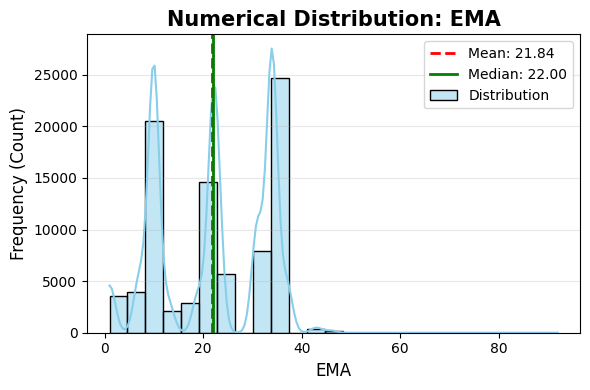

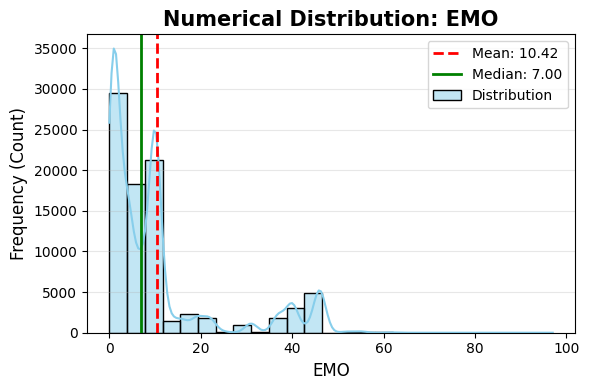

Skipping 'AC_CLASS': This is a categorical/text column.


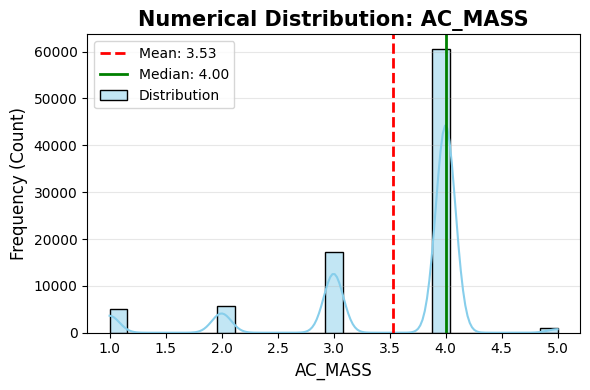

Skipping 'TYPE_ENG': This is a categorical/text column.


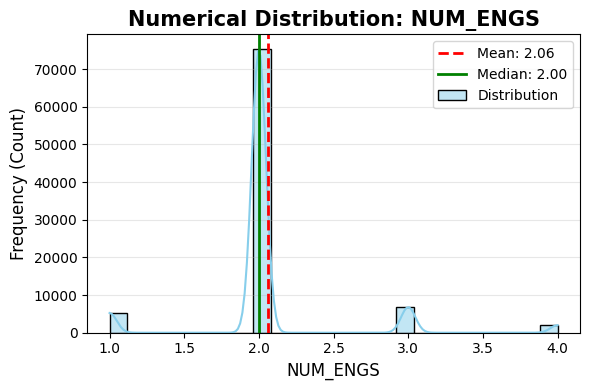

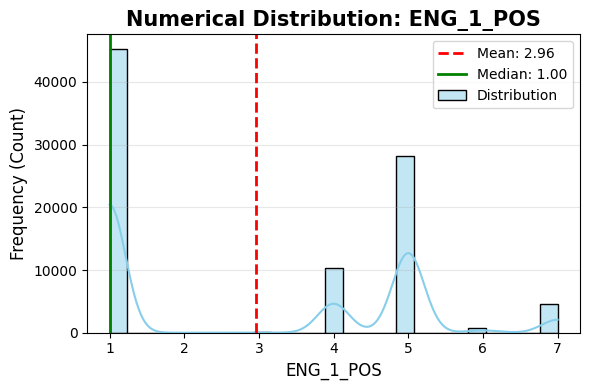

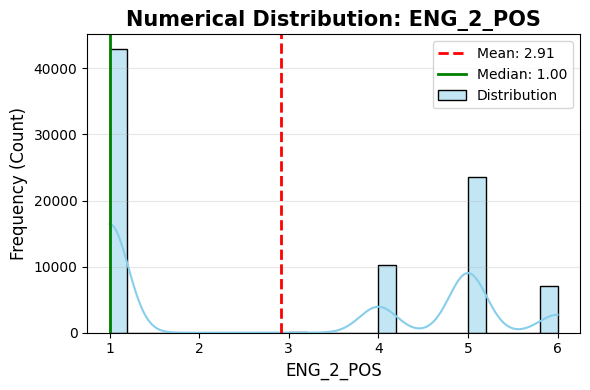

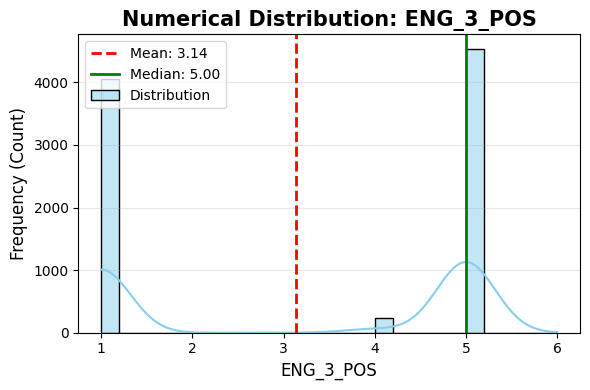

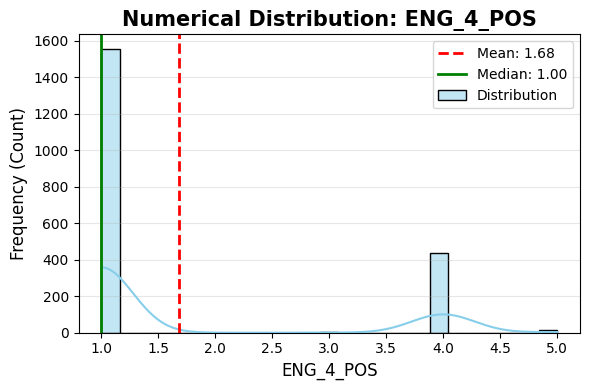

Skipping 'PHASE_OF_FLIGHT': This is a categorical/text column.


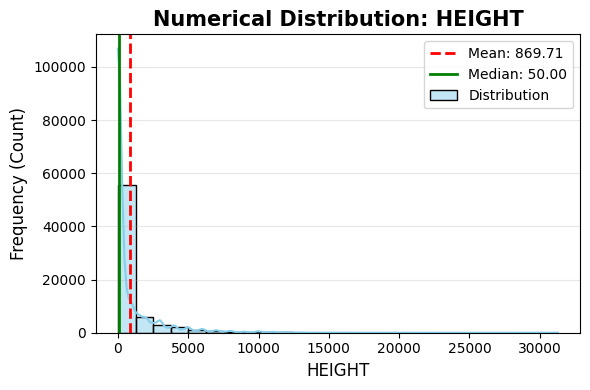

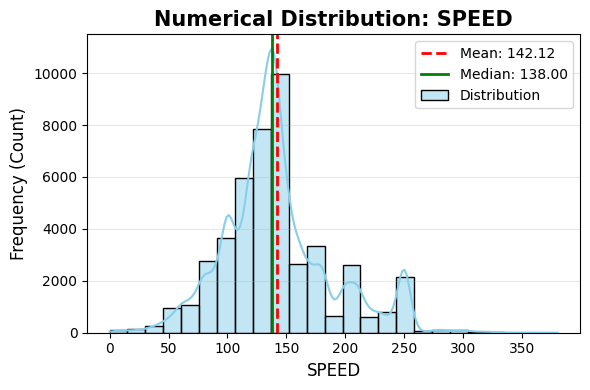

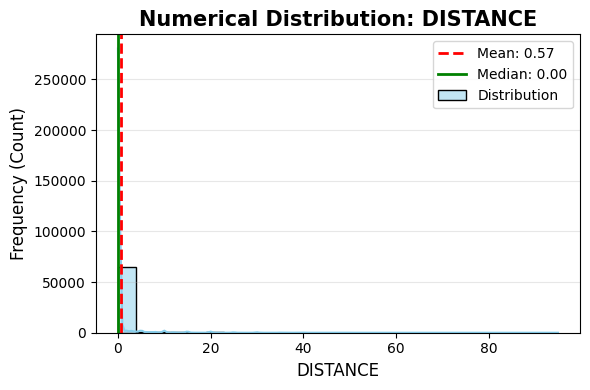

Skipping 'SKY': This is a categorical/text column.
Skipping 'PRECIPITATION': This is a categorical/text column.


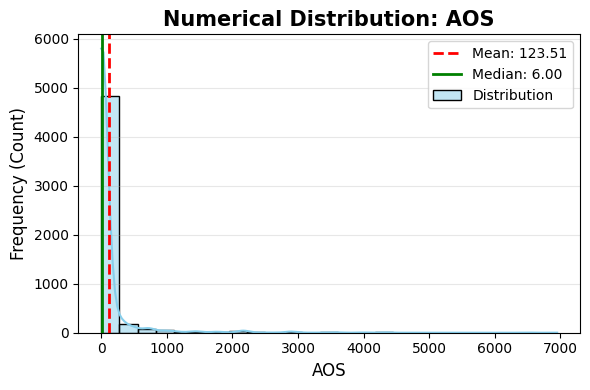

Skipping 'COST_REPAIRS': This is a categorical/text column.
Skipping 'COST_OTHER': This is a categorical/text column.
Skipping 'COST_REPAIRS_INFL_ADJ': This is a categorical/text column.
Skipping 'COST_OTHER_INFL_ADJ': This is a categorical/text column.


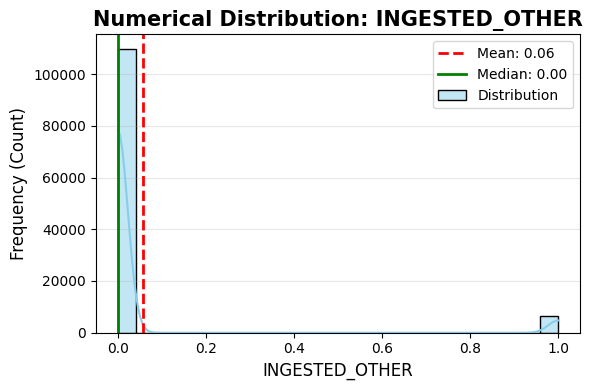

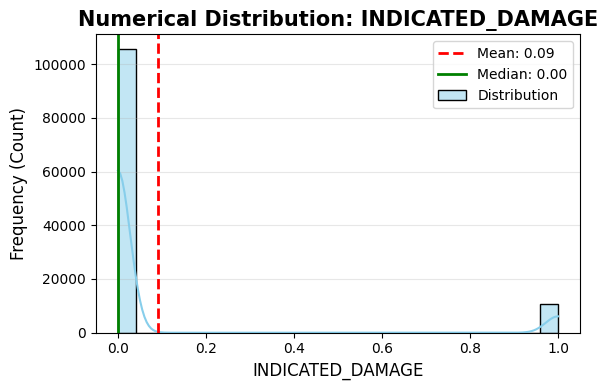

Skipping 'DAMAGE_LEVEL': This is a categorical/text column.


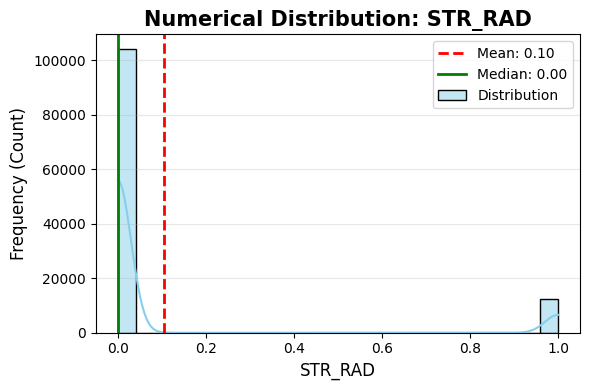

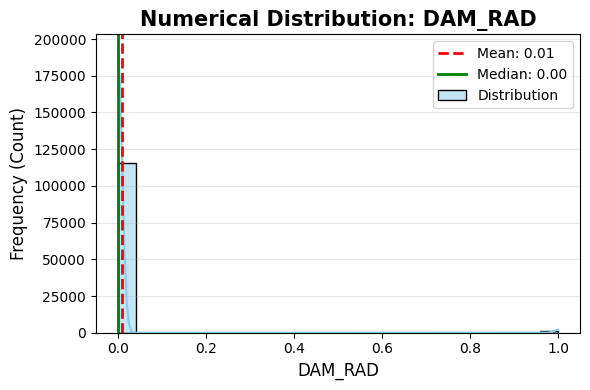

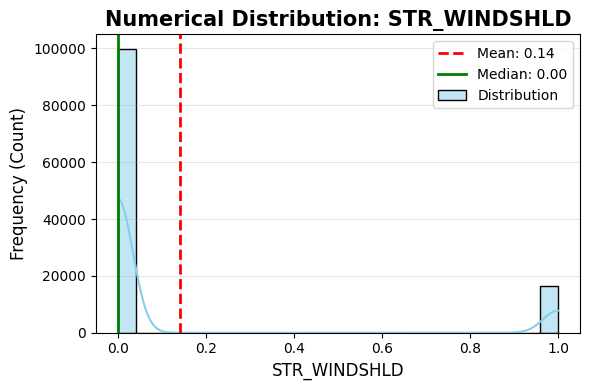

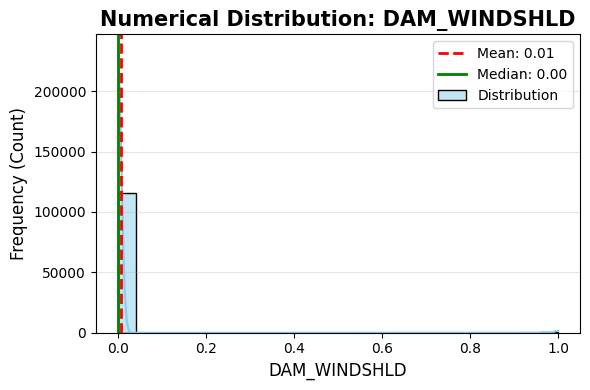

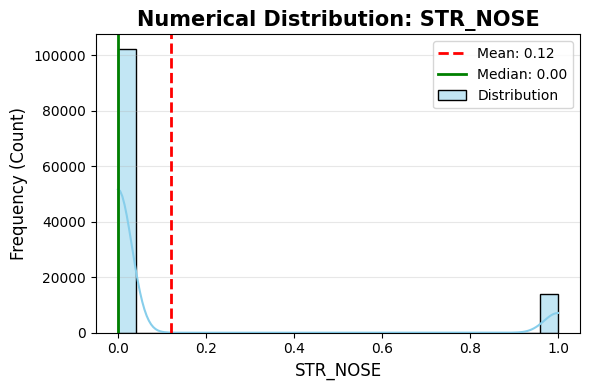

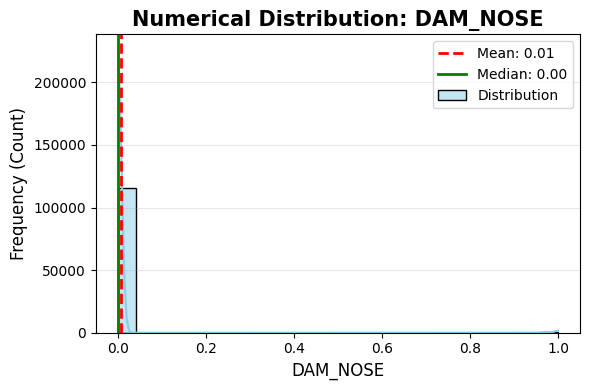

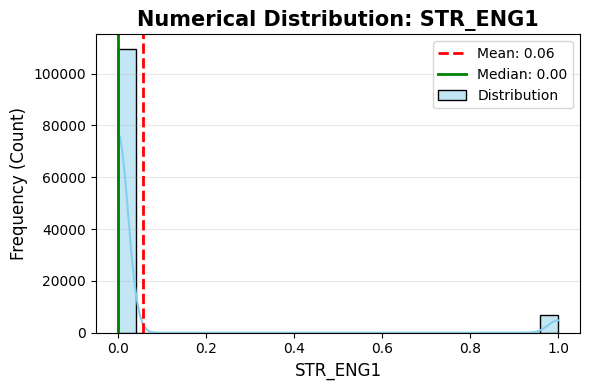

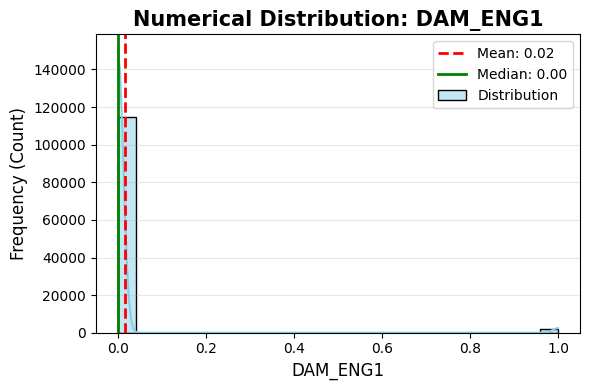

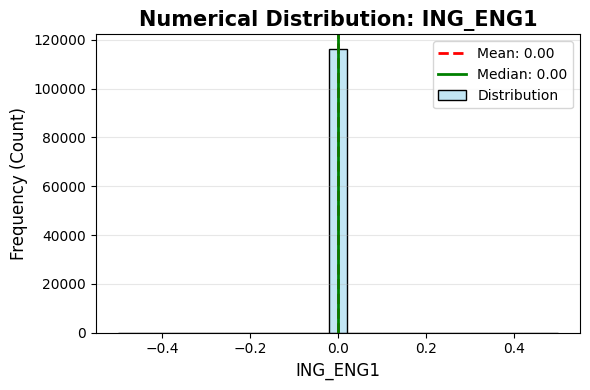

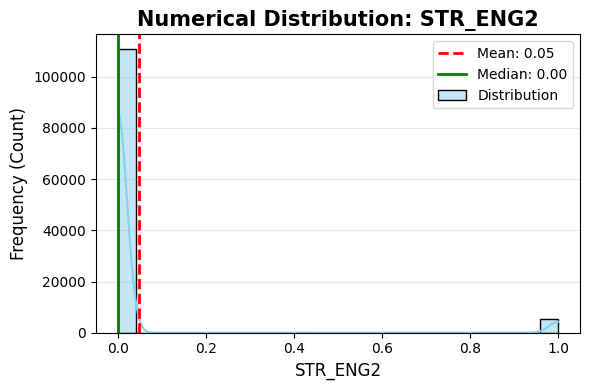

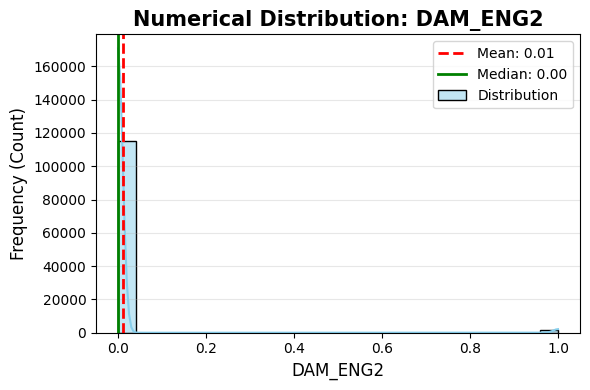

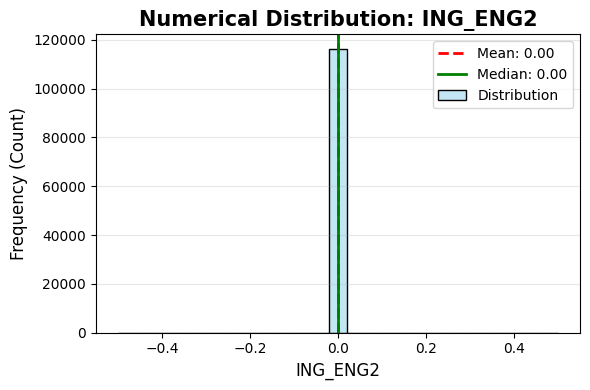

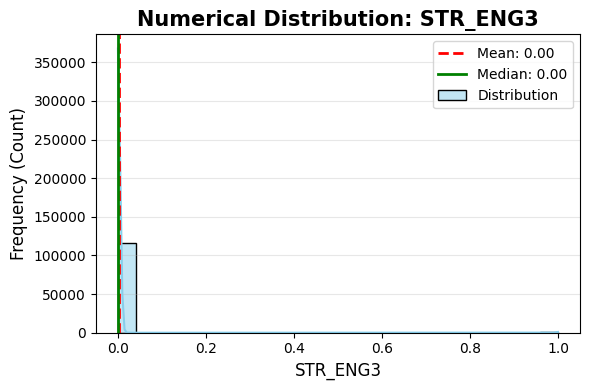

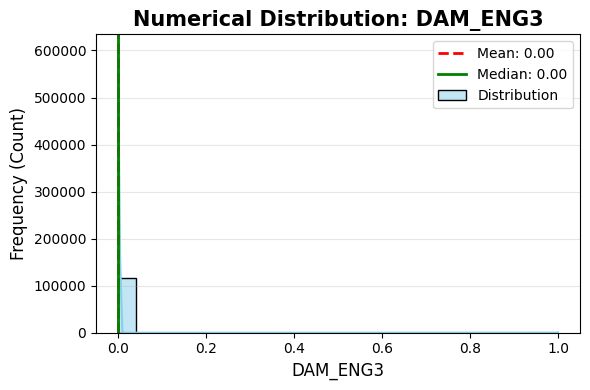

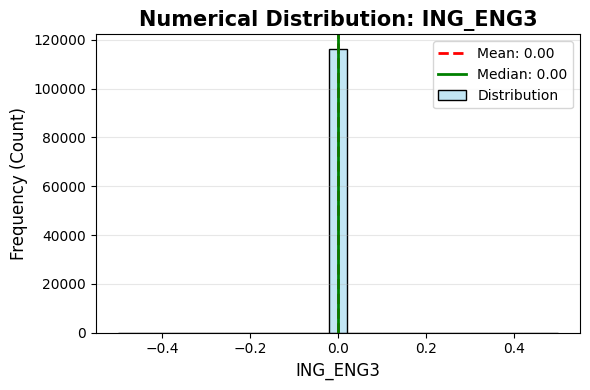

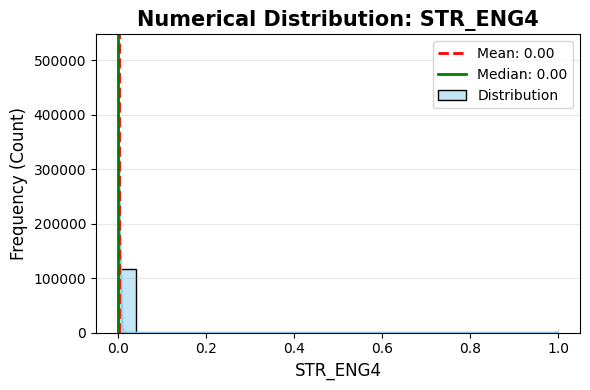

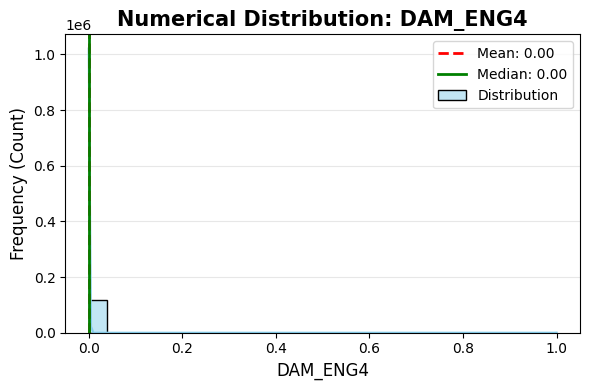

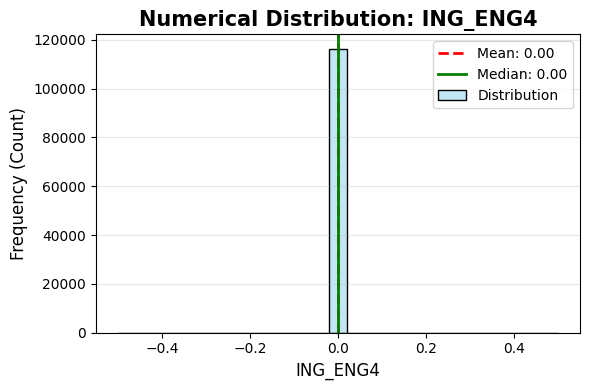

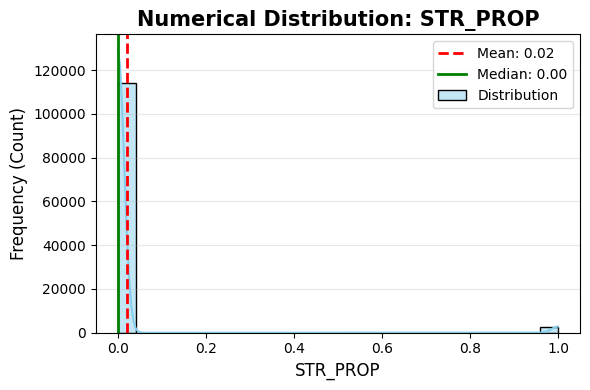

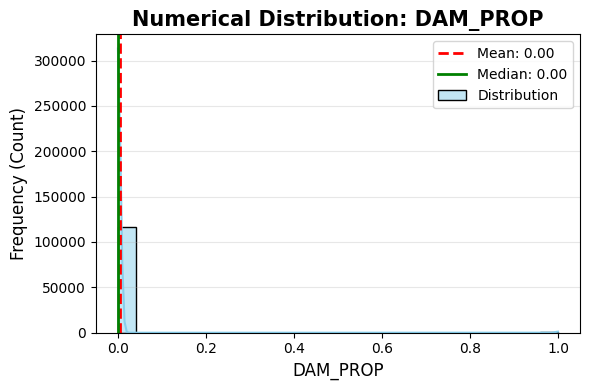

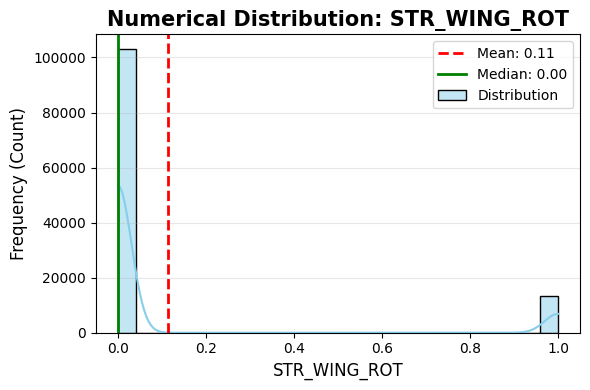

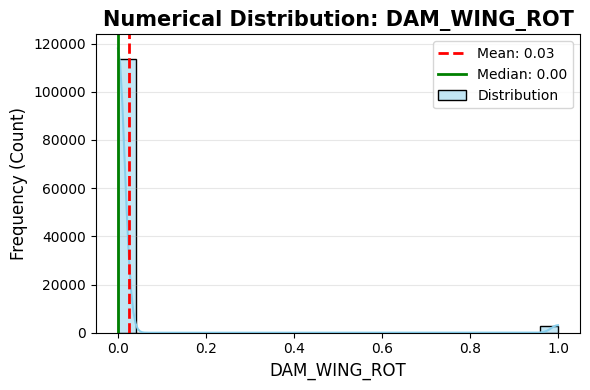

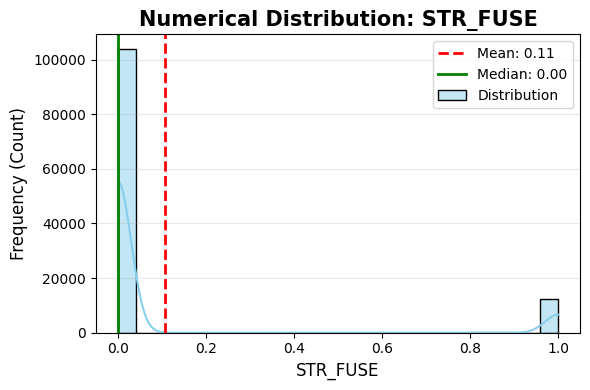

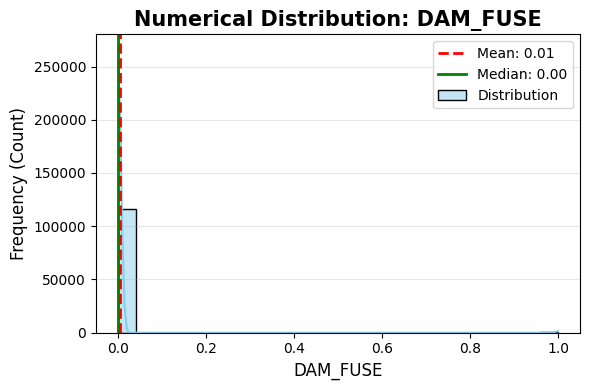

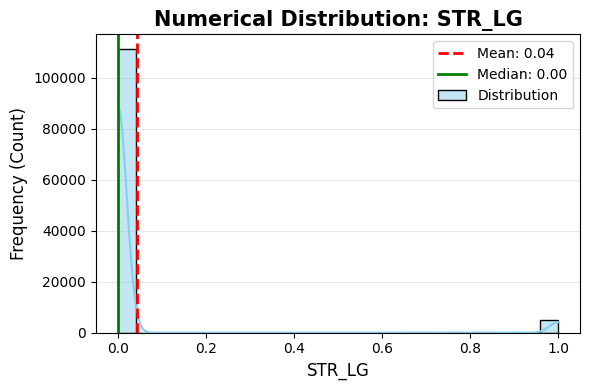

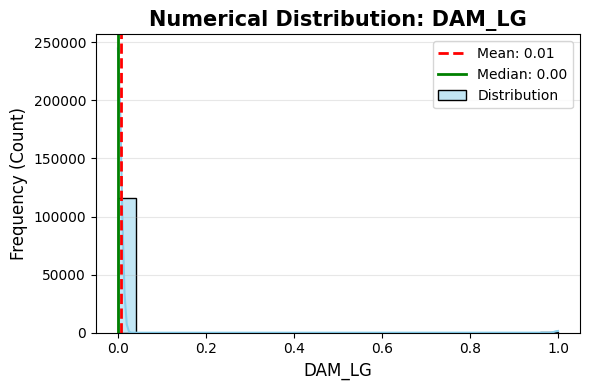

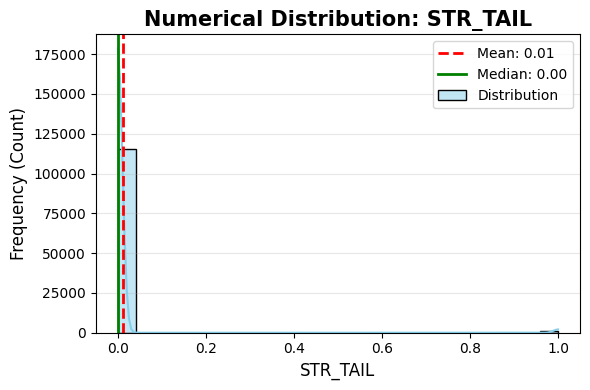

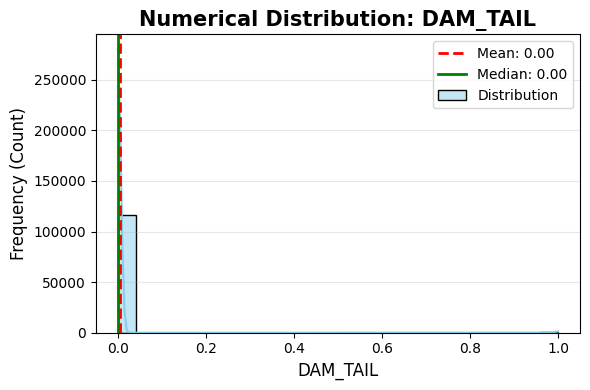

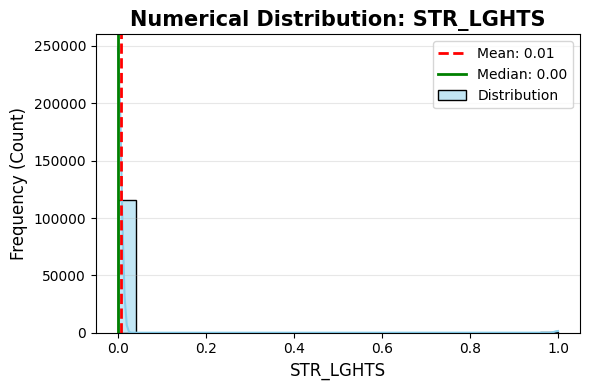

Skipping 'DAM_LGHTS': This is a categorical/text column.
Skipping 'STR_OTHER': This is a categorical/text column.
Skipping 'DAM_OTHER': This is a categorical/text column.
Skipping 'OTHER_SPECIFY': This is a categorical/text column.
Skipping 'EFFECT': This is a categorical/text column.
Skipping 'EFFECT_OTHER': This is a categorical/text column.
Skipping 'BIRD_BAND_NUMBER': The column is entirely empty.
Skipping 'SPECIES_ID': This is a categorical/text column.
Skipping 'SPECIES': This is a categorical/text column.
Skipping 'REMARKS': This is a categorical/text column.
Skipping 'REMAINS_COLLECTED': This is a categorical/text column.
Skipping 'REMAINS_SENT': This is a categorical/text column.
Skipping 'WARNED': This is a categorical/text column.
Skipping 'NUM_SEEN': This is a categorical/text column.
Skipping 'NUM_STRUCK': This is a categorical/text column.
Skipping 'SIZE': This is a categorical/text column.


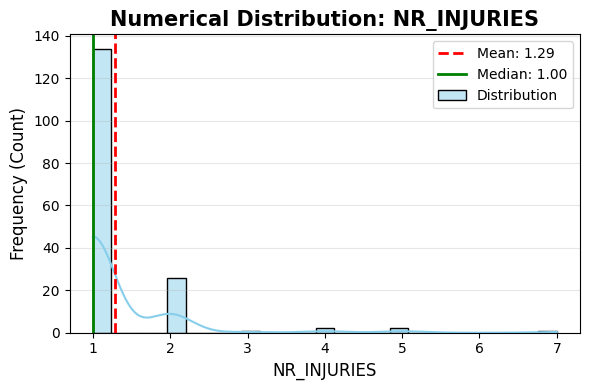

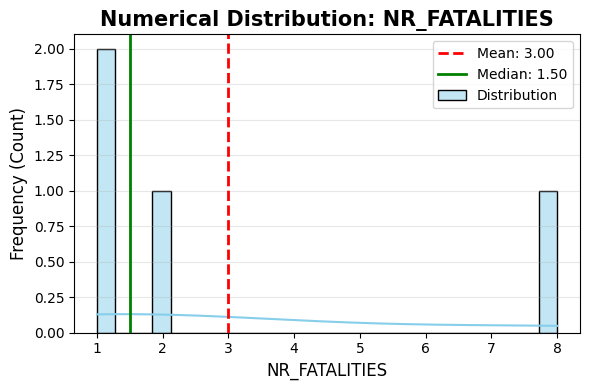

Skipping 'COMMENTS': This is a categorical/text column.
Skipping 'REPORTED_NAME': This is a categorical/text column.
Skipping 'REPORTED_TITLE': This is a categorical/text column.
Skipping 'SOURCE': This is a categorical/text column.
Skipping 'PERSON': This is a categorical/text column.
Skipping 'LUPDATE': This is a categorical/text column.
Skipping 'TRANSFER': This is a categorical/text column.


In [ ]:
def plot_numerical_distribution(df, column):
    """
    Checks if a column is numeric and creates a histogram with KDE,
    mean, and median lines.
    """
    # 1. Safety check: ensure the column exists and is numeric
    if not pd.api.types.is_numeric_dtype(df[column]):
        print(f"Skipping '{column}': This is a categorical/text column.")
        return

    # 2. Clean data for calculation (drop NaNs)
    data = df[column].dropna()

    if data.empty:
        print(f"Skipping '{column}': The column is entirely empty.")
        return

    # 3. Calculate central tendency stats
    mean_val = data.mean()
    median_val = data.median()

    # 4. Initialize the plot
    plt.figure(figsize=(6, 4))

    # Create Histogram with Trend Line (KDE)
    sns.histplot(data, kde=True, color='skyblue', label='Distribution', bins=25)

    # 5. Add vertical markers for Mean and Median
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2,
                label=f'Median: {median_val:.2f}')

    # 6. Styling and Labels
    plt.title(f'Numerical Distribution: {column}', fontsize=15, fontweight='bold')
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Frequency (Count)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Example: Run this for all columns in your bird dataset
for col in df.columns:
    plot_numerical_distribution(df, col)

## A global dataset of directional migration networks of migratory birds

In [ ]:
df_birds = pd.read_excel("Birdmigrationdataset.xls")

In [ ]:
df.describe()

,ID,Migratory route codes,Migration start year,Migration start month,Migration end year,Migration end month,"Continents (1 = North America, 2 = South America, 3 = Europe, 4 = Africa, 5 = Asia, 6 = Oceania)",GPS_xx,GPS_yy,"Migration patterns (1 = Intercontinental migration, 2 = Intracontinental migration)","Migration routes (1 = North America↔North America, 2 = South America↔South America, 3 = Europe↔Europe, 4 = Africa↔Africa, 5 = Asia↔Asia, 6 = Oceania↔Oceania, 7 = Europe→Africa, 8 = Africa→Europe, 9 = North America→South America, 10 = South America→North America, 11 = Europe→Asia, 12 = Asia→Europe, 13 = Asia→Africa, 14 = Africa→Asia, 15 = Europe→North America, 16 = North America→Europe, 17 = Asia→Oceania, 18 = Oceania→Asia, 19 = North America→Oceania, 20 = Oceania→North America, 21 = North America→Asia)",Publish time
count,42844.000000,42844.000000,42844.000000,42844.000000,42844.000000,42844.000000,42844.000000,42844.000000,42844.000000,42844.000000,42844.000000,42844.000000
mean,21422.500000,770.664270,2013.484035,6.647699,2014.155891,8.094552,3.215946,6.306873,29.920635,1.265148,7.339324,2015.137079
std,12368.141803,417.693131,7.953947,2.582533,7.332395,2.913444,1.368586,61.927514,18.893424,0.441417,3.191164,6.017507
min,1.000000,1.000000,1979.000000,1.000000,1979.000000,1.000000,1.000000,-152.212570,-83.450759,1.000000,1.000000,1993.000000
25%,10711.750000,453.000000,2010.000000,4.000000,2012.000000,5.000000,3.000000,-14.416624,14.693913,1.000000,5.000000,2013.000000
50%,21422.500000,757.000000,2016.000000,7.000000,2016.000000,9.000000,3.000000,13.499589,34.386850,1.000000,7.000000,2016.000000
75%,32133.250000,1169.000000,2019.000000,8.000000,2019.000000,10.000000,4.000000,33.385454,44.086396,2.000000,9.000000,2020.000000
max,42844.000000,1454.000000,2023.000000,12.000000,2023.000000,12.000000,6.000000,177.922640,78.887166,2.000000,21.000000,2023.000000


In [ ]:
# General Summary
print(f"Dataset Shape: {df_birds.shape}")
print("\n--- Column Overview ---")
df_birds.info()

Dataset Shape: (42844, 26)

--- Column Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42844 entries, 0 to 42843
Data columns (total 26 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                                                                                                                  

In [ ]:
# Check for missing values
missing_data = df_birds.isnull().sum()
print("Columns with missing values:")
print(missing_data[missing_data > 0])

Columns with missing values:
Provinces    19
dtype: int64


In [ ]:
# Statistical summary for years, months, and coordinates
numerical_cols = ['Migration start year', 'Migration start month', 'GPS_xx', 'GPS_yy']
print(df_birds[numerical_cols].describe())

       Migration start year  Migration start month        GPS_xx        GPS_yy
count          42844.000000           42844.000000  42844.000000  42844.000000
mean            2013.484035               6.647699      6.306873     29.920635
std                7.953947               2.582533     61.927514     18.893424
min             1979.000000               1.000000   -152.212570    -83.450759
25%             2010.000000               4.000000    -14.416624     14.693913
50%             2016.000000               7.000000     13.499589     34.386850
75%             2019.000000               8.000000     33.385454     44.086396
max             2023.000000              12.000000    177.922640     78.887166


/tmp/ipykernel_574/4225922360.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_birds, x='Migration start month', palette='viridis')


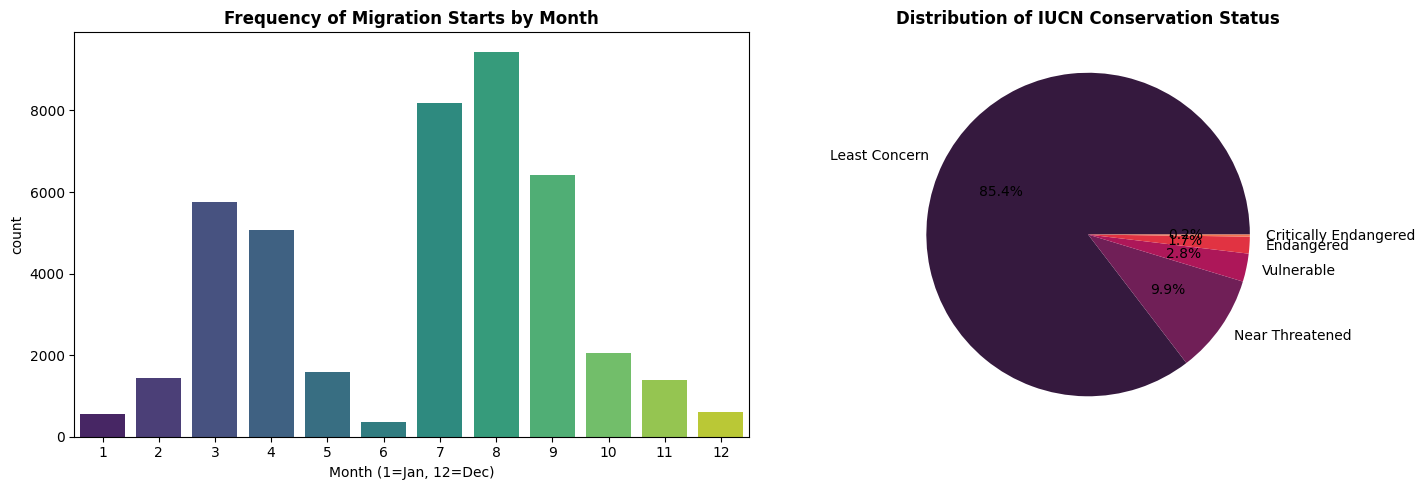

In [ ]:
plt.figure(figsize=(15, 5))

# Plot 1: Migration Timing (Seasonality)
plt.subplot(1, 2, 1)
sns.countplot(data=df_birds, x='Migration start month', palette='viridis')
plt.title("Frequency of Migration Starts by Month", fontweight='bold')
plt.xlabel("Month (1=Jan, 12=Dec)")

# Plot 2: Conservation Status
plt.subplot(1, 2, 2)
df_birds['The IUCN Red List (2023)'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('rocket'))
plt.title("Distribution of IUCN Conservation Status", fontweight='bold')
plt.ylabel("")

plt.tight_layout()
plt.show()